# From SDSS to Posterior: Fitting Real Galaxy Data

Every astronomer's first question: how do I fit *my* data? This notebook
shows the complete workflow from loading observed data to posterior analysis.

**Note**: This is a workflow demo, not a scientific analysis. For real
science, you'd also consider noise models, calibration systematics, and
emission line treatment.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
)

import sys, os  # noqa: E401, E402
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("demonstrations", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, plot_sfh, safe_corner, setup_style  # noqa: E402

setup_style()

In [2]:
ssp_data = load_ssp_data(
    "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
)
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

## Loading and Preparing Data

For this demo, we simulate "real" data by generating a mock with realistic
noise properties. Replace this cell with your own data loading code.

In [3]:
# Simulate "real" SDSS-like spectrum
# In practice: load from FITS file, trim wavelength, mask bad pixels
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
REDSHIFT = 0.05  # known spectroscopic redshift

spec = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(REDSHIFT),
    mean_sfh_type="tsnorm",
)
model = Model(spec, ssp_data, filters=filters)
model.precompute_spectroscopy(WAVE_OBS)

# Generate a "real" galaxy (in practice, load from file)
true_params = spec.sample(jax.random.PRNGKey(42))
# Override tsnorm to a typical star-forming galaxy (still forming stars now)
true_params = {**true_params}
true_params["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
true_params["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
true_params["sfh_tsnorm_skew"] = jnp.array(-0.5)
true_params["sfh_tsnorm_trunc"] = jnp.array(2.0)
mock = model.mock_spectrum(true_params, WAVE_OBS, snr=25.0, key=jax.random.PRNGKey(1))

# This is your data:
flux_obs = mock.flux_obs    # shape (200,)
noise = mock.noise          # shape (200,), per-pixel uncertainties

W0321 17:47:29.186152 15140360 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_39945/246906633.py:19: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model = Model(spec, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_39945/246906633.py:20: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model.precompute_spectroscopy(WAVE_OBS)


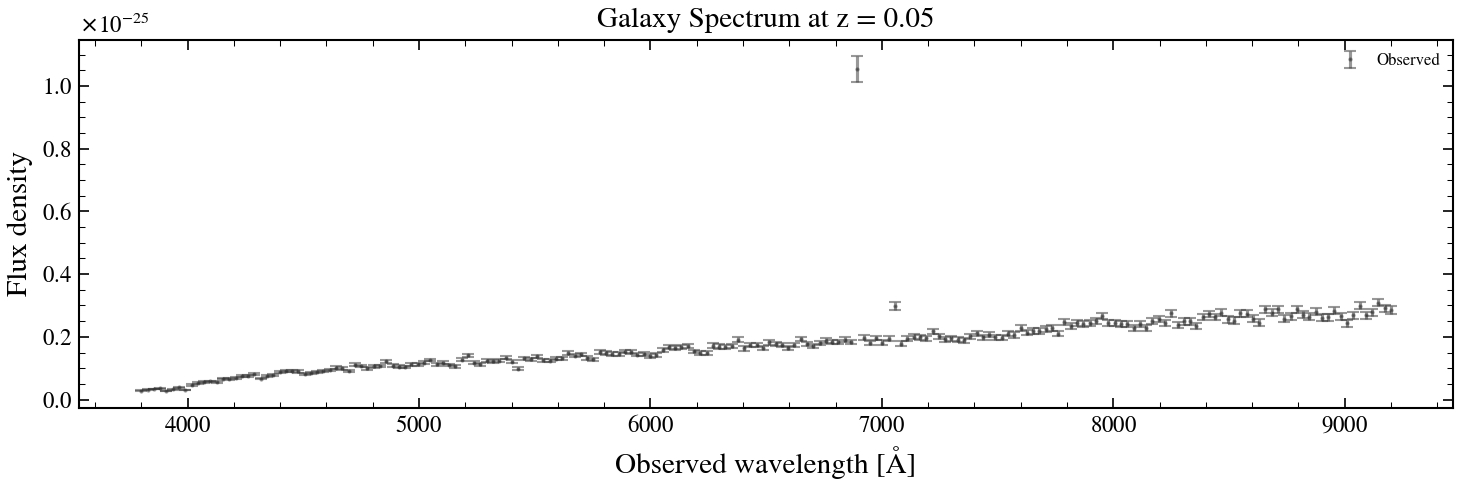

In [4]:
# --- FIGURE 1: "Real" spectrum ---
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.errorbar(
    np.array(WAVE_OBS), np.array(flux_obs), yerr=np.array(noise),
    fmt=".", ms=2, color=COLORS["data"], alpha=0.5, label="Observed",
)
ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("Flux density")
ax.set_title(f"Galaxy Spectrum at z = {REDSHIFT}")
ax.legend(fontsize=8)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_real_spectrum.png"), dpi=150, bbox_inches="tight")
plt.show()

## Fitting

In [5]:
fitter = Fitter(model, flux_obs, noise, data_type="spectroscopy")

# MAP initialization
result_map = fitter.run("map", n_steps=500, verbose=False)

# native_geovi inference
result = fitter.run(
    "native_geovi", n_iterations=15, n_samples=6, n_seeds=5,
    n_posterior_samples=5000, verbose=False,
)
print(f"Fit: {result.wall_time_s:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


Fit: 123.6s


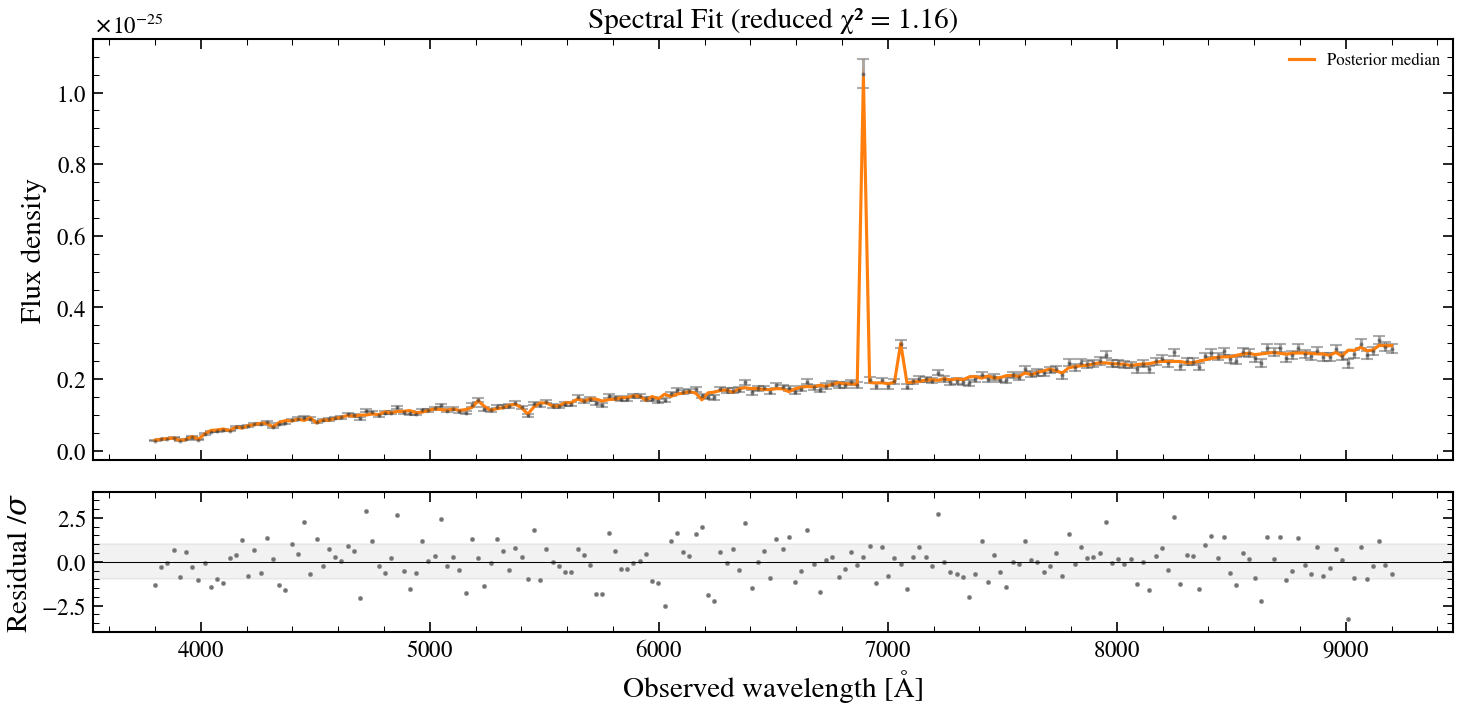

In [6]:
# --- FIGURE 2: Spectral fit ---
draws = []
for i in range(50):
    idx = i % len(result.samples[spec.free_params[0]])
    p = {k: v[idx] for k, v in result.samples.items()}
    draws.append(np.array(model.predict_spectrum(p)))
draws = np.array(draws)
med = np.median(draws, axis=0)

fig, (ax_f, ax_r) = plt.subplots(
    2, 1, figsize=(10, 5), gridspec_kw={"height_ratios": [3, 1]}, sharex=True
)
w = np.array(WAVE_OBS)
ax_f.errorbar(w, np.array(flux_obs), yerr=np.array(noise),
              fmt=".", ms=2, color=COLORS["data"], alpha=0.4)
for d in draws[:30]:
    ax_f.plot(w, d, color=COLORS["geovi"], alpha=0.04, lw=0.5)
ax_f.plot(w, med, color=COLORS["geovi"], lw=1.5, label="Posterior median")
ax_f.legend(fontsize=8)
ax_f.set_ylabel("Flux density")

res = (np.array(flux_obs) - med) / np.array(noise)
ax_r.scatter(w, res, s=2, c=COLORS["data"], alpha=0.5)
ax_r.axhline(0, color="k", lw=0.5)
ax_r.axhspan(-1, 1, alpha=0.1, color="grey")
ax_r.set_ylim(-4, 4)
ax_r.set_ylabel(r"Residual /$\sigma$")
ax_r.set_xlabel("Observed wavelength [Å]")

chi2 = np.sum(res**2) / len(res)
ax_f.set_title(f"Spectral Fit (reduced χ² = {chi2:.2f})")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_spectral_fit.png"), dpi=150, bbox_inches="tight")
plt.show()

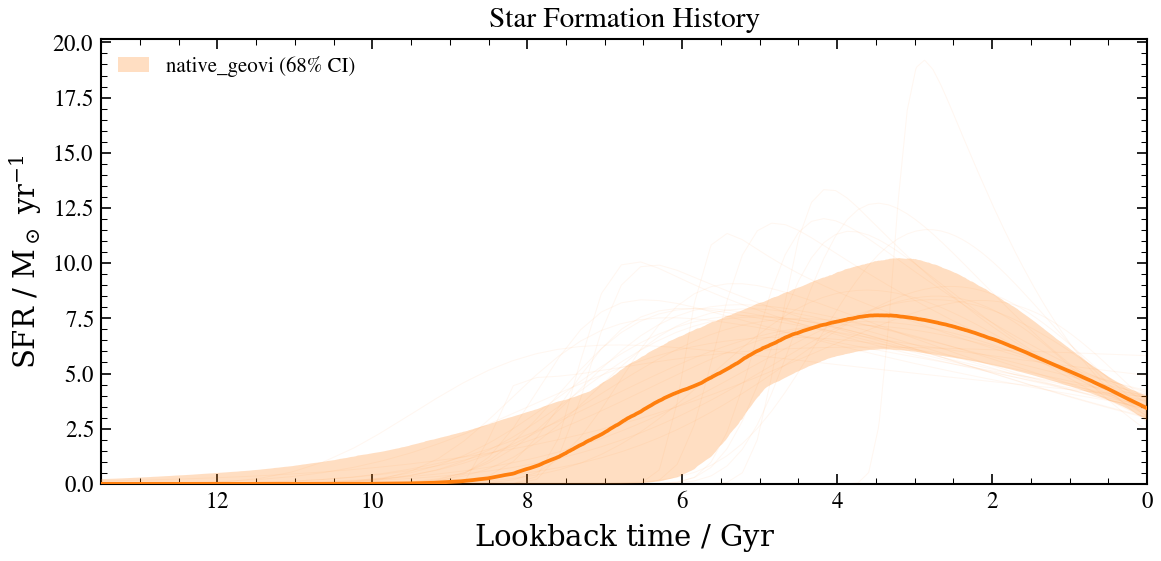

In [7]:
# --- FIGURE 3: SFH posterior ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(model, result, ax=ax, color=COLORS["geovi"], label="native_geovi", method="geoVI")
ax.set_title("Star Formation History")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_sfh.png"), dpi=150, bbox_inches="tight")
plt.show()

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

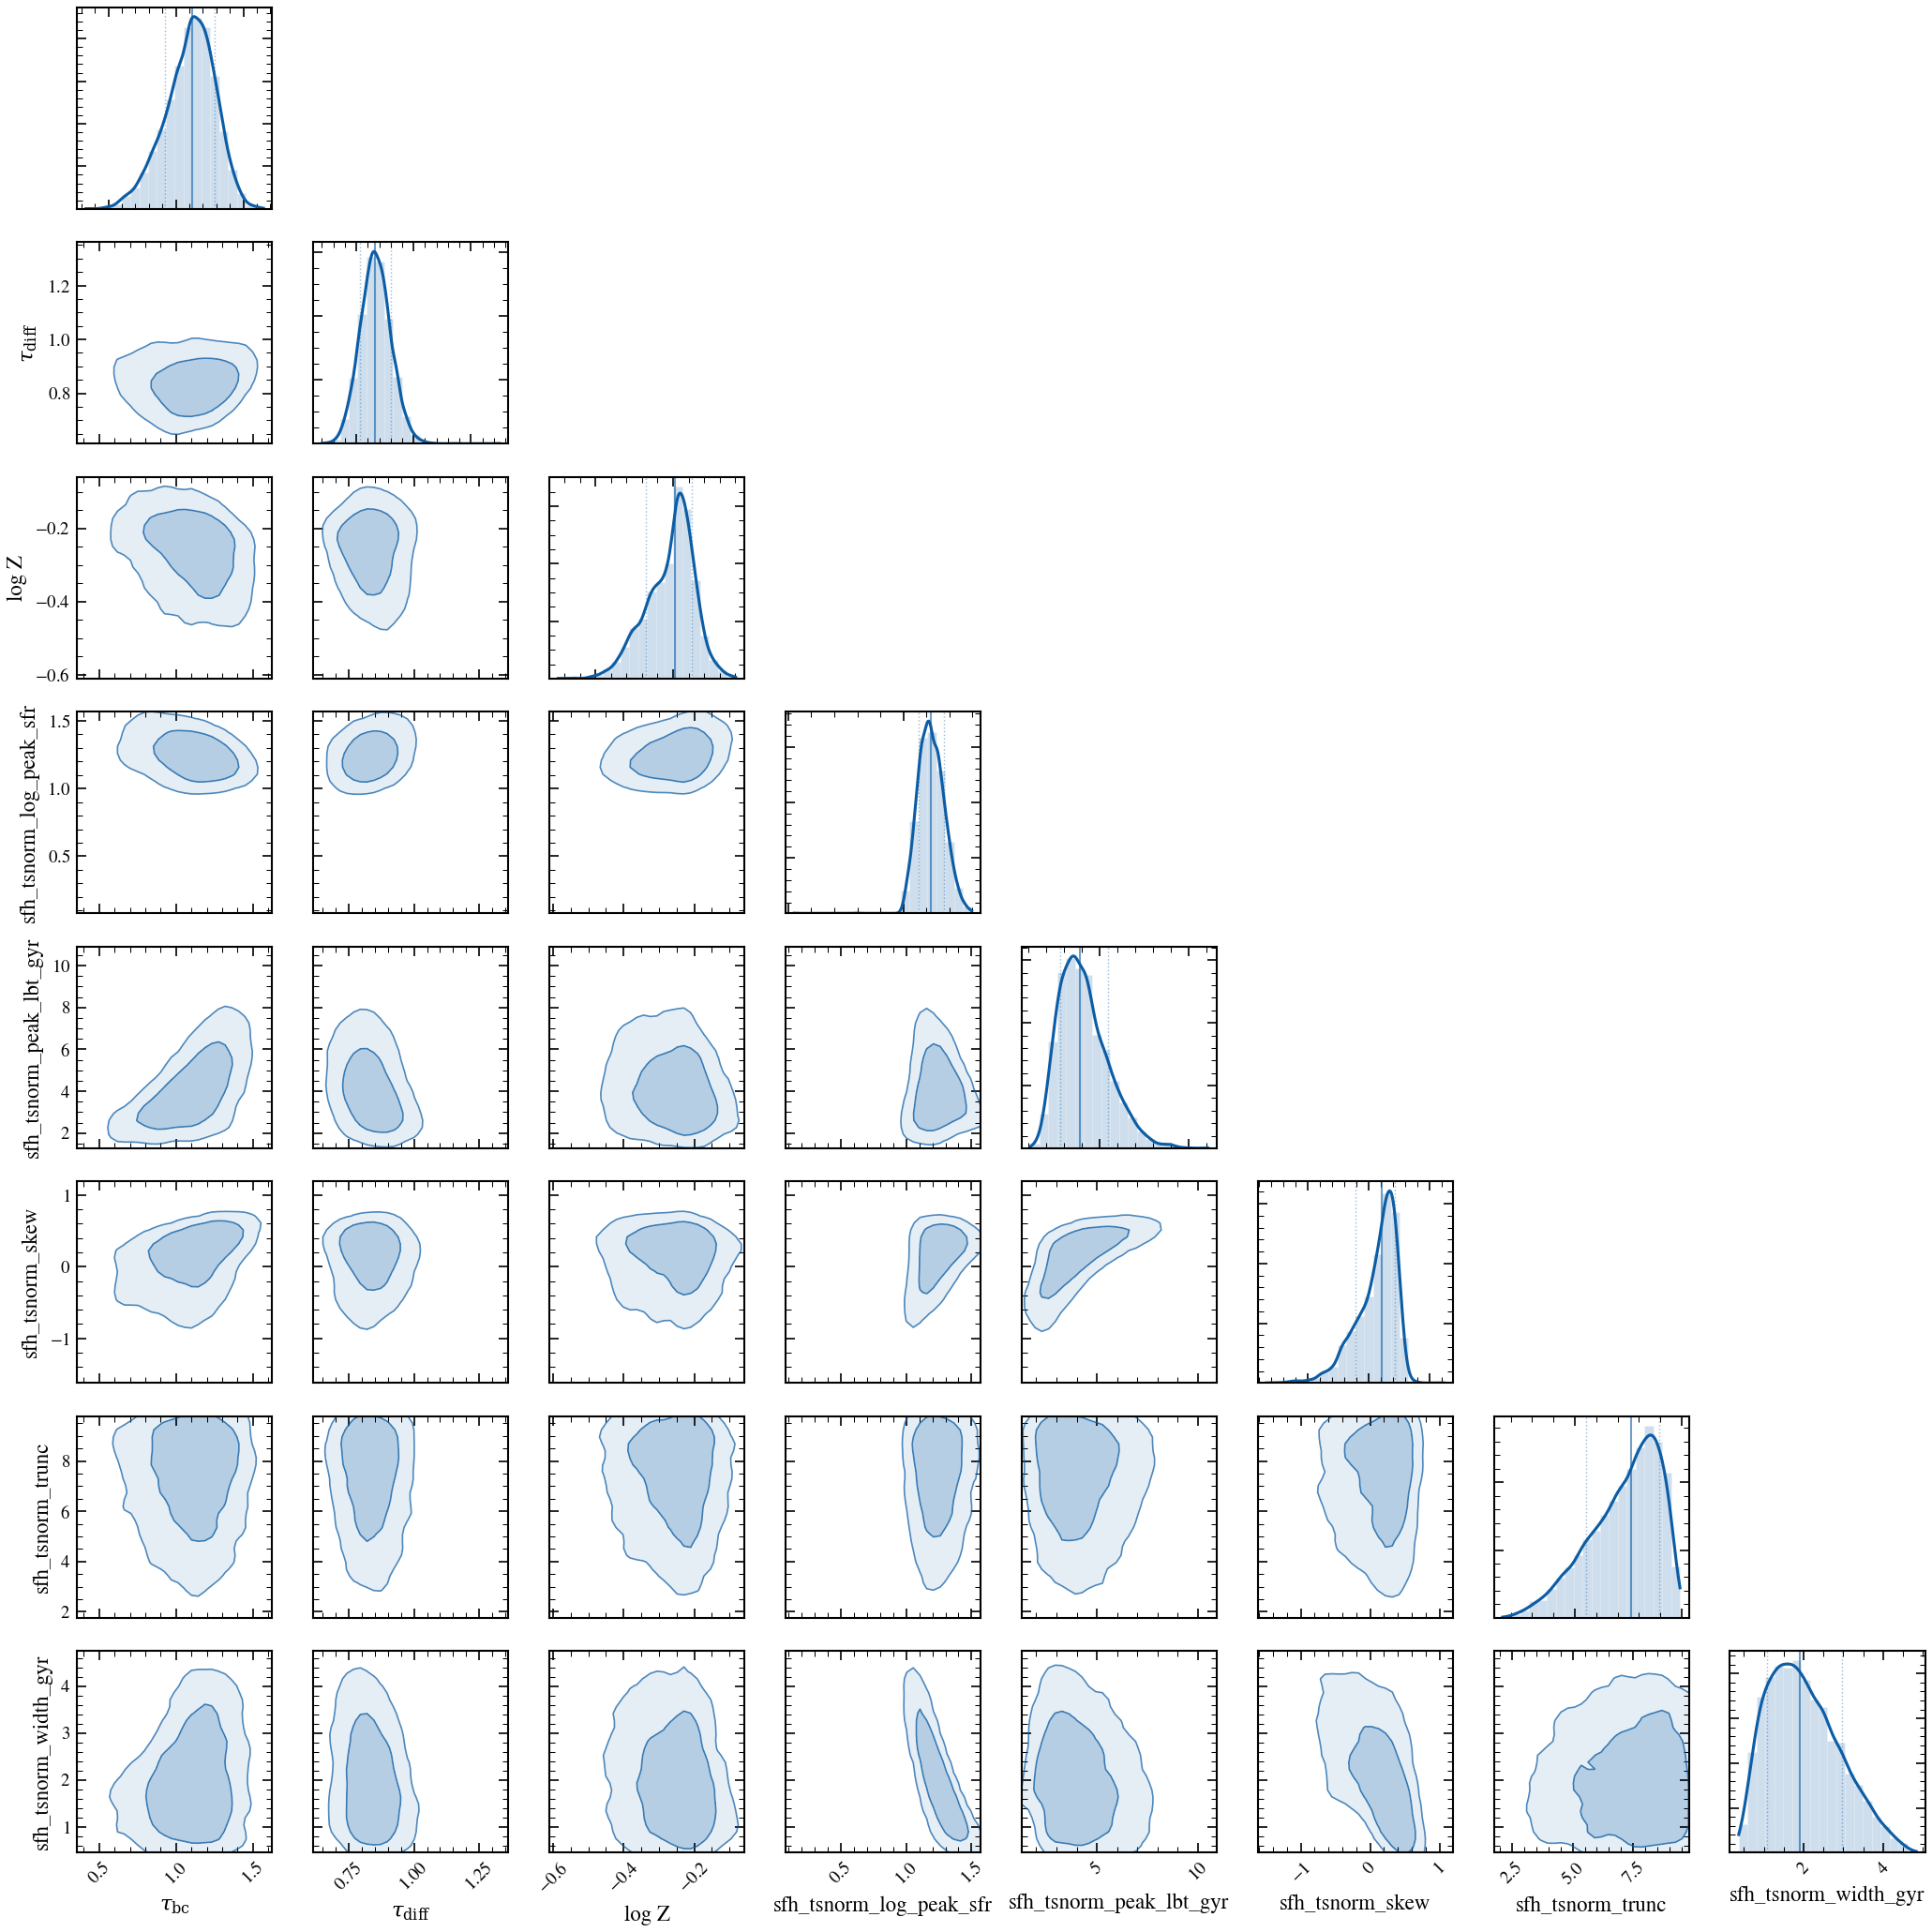

In [8]:
# --- FIGURE 4: Corner plot ---
fig = safe_corner(result)
if fig is not None:
    plt.savefig(os.path.join(FIGDIR, "fig04_corner.png"), dpi=150, bbox_inches="tight")
plt.show()

## Loading Your Own Data

Replace the mock generation with your data loader:

```python
from astropy.io import fits

hdu = fits.open("my_spectrum.fits")
wave_obs = hdu[1].data["wavelength"]  # observed-frame Angstrom
flux_obs = hdu[1].data["flux"]
noise = hdu[1].data["ivar"]**(-0.5)   # convert inverse variance to sigma

# Mask bad pixels
good = (noise > 0) & (noise < 1e10) & np.isfinite(flux_obs)
wave_obs = jnp.array(wave_obs[good])
flux_obs = jnp.array(flux_obs[good])
noise = jnp.array(noise[good])
```

Then proceed with `Model`, `Fitter`, and `native_geovi` as above.

## Caveats

1. **Noise model**: Real data has wavelength-dependent systematics.
   Consider the calibration floor noise model (reference/06).
2. **Emission lines**: Strong emitters may need line marginalization
   or masking (reference/05).
3. **Resolution**: Convolve templates to match data spectral resolution.
4. **Model adequacy**: Check residuals for systematic patterns.